In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import DataLoader, TensorDataset

from split.create_split import create_split
from models.random_forest import RandomForestPredictor
from main_scorer import plot_results, plot_umap_embedding
from models.oracle import build_oracle_df, oracle_lookup
from models.lstm_goaldirected import LSTMGoalDirected

SEED = 42

/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Train LSTM with Reniforcement Learning - TFBind8

In [2]:
# Load dataset: TFBIND 8 - SIX6 REF R1
df = pd.read_csv('tf_bind_8-SIX6_REF_R1/dataset.csv')

# Add a column encoded sequence instead of the cols 0-7
df['encoded_sequence'] = df.apply(lambda row: [row[str(i)] for i in range(8)], axis=1)
df['split'] = ['None'] * len(df)

# Create train/test splits
df = create_split(df, k_seeds=50, n_training_seeds=20, random_state=42)

# Prepare training data
train_df = df[df['split'] == 'train']
x = train_df.iloc[:, :-6].values
y = train_df['binding_scores'].values
# One-hot encode and reshape to 3D for LSTM (samples, timesteps, features)
x_one_hot = np.array([tf.one_hot(seq, depth=4).numpy() for seq in x])
X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=SEED)
# check sizes of testsplits
df['split'].value_counts()


split
test_c    38796
test_a    10614
train      8670
test_b     7712
Name: count, dtype: int64

In [3]:
rf = RandomForestPredictor()
rf.train(X_train, y_train)
rf.evaluate(X_val, y_val)

Training Random Forest model...
Training completed.
R2 Score: 0.15918116792162462
MSE: 0.004913541466129367
Spearman Correlation: 0.3804121548809125


{'r2': 0.15918116792162462,
 'mse': 0.004913541466129367,
 'spearman_correlation': np.float64(0.3804121548809125)}

In [4]:
X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [5]:
def train_goal_directed_model(model, loader, epochs=20, lr= 0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    model.train()

    for epoch in range(epochs):
        epoch_loss = 0
        for batch_x, batch_y in loader:
            optimizer.zero_grad()

            input = batch_x[:, :-1]
            target_part = batch_x[:, 1:]
            logits, _ = model(input, batch_y)
            loss = criterion(logits.reshape(-1, model.vocab_size), target_part.reshape(-1))

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        if epoch+1 % 5 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(loader)}')

### Improved RF Loop:
- added a diversity filtering for selected sequences for retraining: hamming distance need to be larger than a threshold
- training data is now mixed with original training data (prevention of forgetting)
- entropy is regularized: low-entropy output is penalized during training
- temperature is increasing over iterations to have more exploration

this should prevent the approach from suggesting always the same sequence after a couple of steps. 

In [6]:
def train_goal_directed_model_v2(model, loader, epochs=20, lr=0.001, entropy_weight=0.01):
    """Training with entropy regularization to prevent mode collapse."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    model.train()

    for epoch in range(epochs):
        epoch_loss = 0
        for batch_x, batch_y in loader:
            optimizer.zero_grad()

            input = batch_x[:, :-1]
            target_part = batch_x[:, 1:]
            logits, _ = model(input, batch_y)
            ce_loss = criterion(logits.reshape(-1, model.vocab_size), target_part.reshape(-1))

            # Entropy regularization: encourage diverse token predictions
            # penalize low-entropy output distris during training to prevent mode collapse
            probs = torch.softmax(logits, dim=-1)
            entropy = -(probs * torch.log(probs + 1e-8)).sum(dim=-1).mean()
            loss = ce_loss - entropy_weight * entropy  # maximize entropy

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        if epoch % 5 == 0:
            print(f'Epoch {epoch}/{epochs}, Loss: {epoch_loss/len(loader):.4f}')


def diversity_filter(sequences, scores, real_scores, min_hamming=2):
    """Greedily pick sequences that are at least min_hamming apart."""
    selected_idx = [0]
    for i in range(1, len(sequences)):
        is_diverse = True
        for j in selected_idx:
            dist = np.sum(sequences[i] != sequences[j])
            if dist < min_hamming:
                is_diverse = False
                break
        if is_diverse:
            selected_idx.append(i)
    idx = np.array(selected_idx)
    return sequences[idx], scores[idx], real_scores[idx]


def rl_loop_v2(model, scorer, oracle, num_iterations=6, batch_size=128,
               X_train=None, y_train=None, GB1=False,
               min_hamming=2, replay_fraction=0.3, temp_start=0.8, temp_end=1.5,
               entropy_weight=0.01):
    """Improved RL loop"""
    values = {'mutation': [], 'predicted_score': [], 'real_score': [], 'iteration': []}
    
    # Keep original training data for replay
    replay_x = torch.LongTensor(X_train)
    replay_y = torch.FloatTensor(y_train).view(-1, 1)
    
    for i in range(num_iterations):
        # Anneal temperature: increase over iterations to maintain exploration
        temp = temp_start + (temp_end - temp_start) * (i / max(num_iterations - 1, 1))
        print(f'-------- Iteration {i+1}/{num_iterations} (temp={temp:.2f}) --------')
        
        ### Propose new sequences
        new_sequences = []
        for _ in range(batch_size):
            seq = model.generate(goal_score=1.1, temp=temp)
            new_sequences.append(seq)

        new_sequences_np = np.array(new_sequences)
        
        ### Score new sequences by RF
        scores = np.array([scorer.predict(seq) for seq in new_sequences_np])

        ### Lookup oracle for real scores
        real_scores = []
        for seq in new_sequences_np:
            if GB1:
                seq_one_hot = tf.one_hot(seq, depth=20).numpy()
                real_score = oracle.inference(torch.tensor(seq_one_hot.flatten(), dtype=torch.float32)).item()
            else:
                real_score = oracle_lookup(oracle, seq)
            real_scores.append(real_score)
        real_scores_np = np.array(real_scores)

        ### Select top 20% sequences based on real scores
        threshold = np.percentile(real_scores_np, 80)
        top_mask = real_scores_np >= threshold
        top_sequences = new_sequences_np[top_mask]
        top_scores = scores[top_mask]
        top_real_scores = real_scores_np[top_mask]

        ### Diversity filter: remove near-duplicates
        if len(top_sequences) > 1:
            top_sequences, top_scores, top_real_scores = diversity_filter(
                top_sequences, top_scores, top_real_scores, min_hamming=min_hamming
            )

        n_unique = len(top_sequences)
        print(f'Avg proposed: {np.mean(scores):.4f}, Avg real: {np.mean(real_scores_np):.4f}, '
              f'Top 20% avg: {np.mean(top_scores):.4f}, Unique diverse: {n_unique}')

        # Append for plotting
        values['mutation'].extend(top_sequences)
        values['predicted_score'].extend(top_scores)
        values['real_score'].extend(top_real_scores)
        values['iteration'].extend([i] * n_unique)
        
        #mix new top sequences with original training data
        x_new = torch.LongTensor(top_sequences)
        y_new = torch.FloatTensor(top_scores).view(-1, 1)
        
        n_replay = int(len(x_new) * replay_fraction / (1 - replay_fraction))
        n_replay = min(n_replay, len(replay_x))
        replay_idx = torch.randperm(len(replay_x))[:n_replay]
        
        x_combined = torch.cat([x_new, replay_x[replay_idx]])
        y_combined = torch.cat([y_new, replay_y[replay_idx]])
        
        dataloader = DataLoader(TensorDataset(x_combined, y_combined), batch_size=16, shuffle=True)
        train_goal_directed_model_v2(model, dataloader, epochs=20, lr=0.001, entropy_weight=entropy_weight)

    return values

Epoch 0/50, Loss: 1.3407
Epoch 5/50, Loss: 1.2998
Epoch 10/50, Loss: 1.2780
Epoch 15/50, Loss: 1.2613
Epoch 20/50, Loss: 1.2520
Epoch 25/50, Loss: 1.2439
Epoch 30/50, Loss: 1.2371
Epoch 35/50, Loss: 1.2304
Epoch 40/50, Loss: 1.2241
Epoch 45/50, Loss: 1.2189
Training Random Forest model...
Training completed.
R2 Score: 0.1591811679216245
MSE: 0.004913541466129368
Spearman Correlation: 0.3804121548809125
-------- Iteration 1/6 (temp=0.80) --------
Avg proposed: 0.3595, Avg real: 0.6412, Top 20% avg: 0.3641, Unique diverse: 20
Epoch 0/20, Loss: 2.1529
Epoch 5/20, Loss: 1.3219
Epoch 10/20, Loss: 1.0467
Epoch 15/20, Loss: 0.9581
-------- Iteration 2/6 (temp=0.94) --------
Avg proposed: 0.3634, Avg real: 0.8188, Top 20% avg: 0.3638, Unique diverse: 3
Epoch 0/20, Loss: 1.1732
Epoch 5/20, Loss: 0.8886
Epoch 10/20, Loss: 0.7006
Epoch 15/20, Loss: 0.5655
-------- Iteration 3/6 (temp=1.08) --------
Avg proposed: 0.3663, Avg real: 0.8505, Top 20% avg: 0.3649, Unique diverse: 4
Epoch 0/20, Loss: 0.

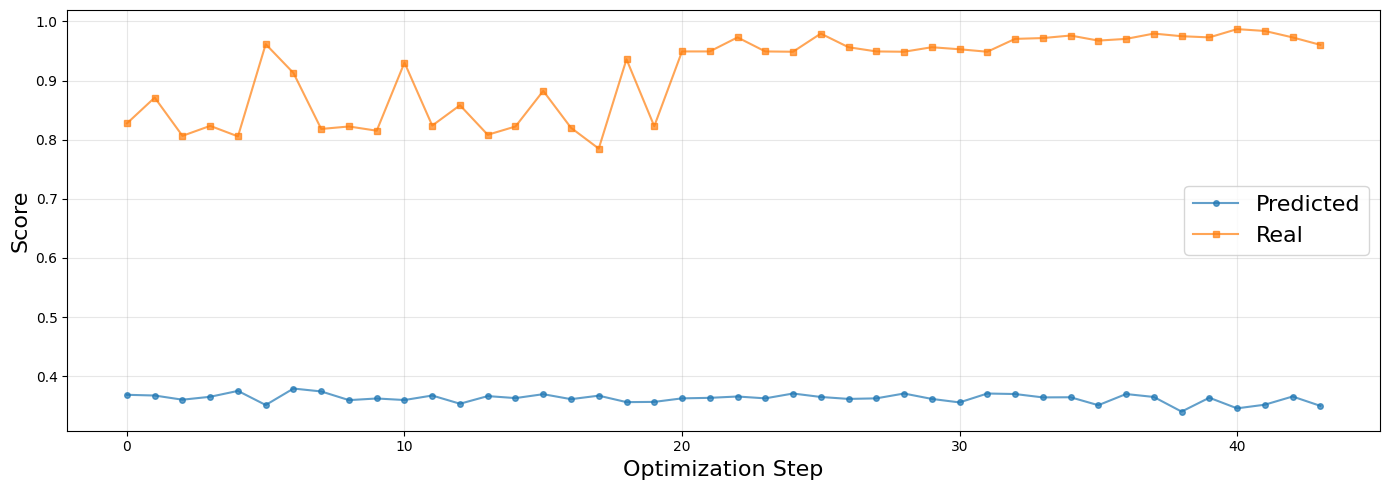

In [7]:
model = LSTMGoalDirected(vocab_size=4, embedding_dim=16, seq_len=8, hidden_dim=64)
#First train the model on the original trianing data
train_goal_directed_model_v2(model, train_loader, epochs=50, lr=0.001)

rf = RandomForestPredictor()
rf.train(X_train, y_train)
rf.evaluate(X_val, y_val)

oracle = build_oracle_df(df)

values = rl_loop_v2(model, rf, oracle, num_iterations=6, batch_size=128, X_train=X_train, y_train=y_train)
values_df = pd.DataFrame(values)
values_df.head()
plot_results(values_df)

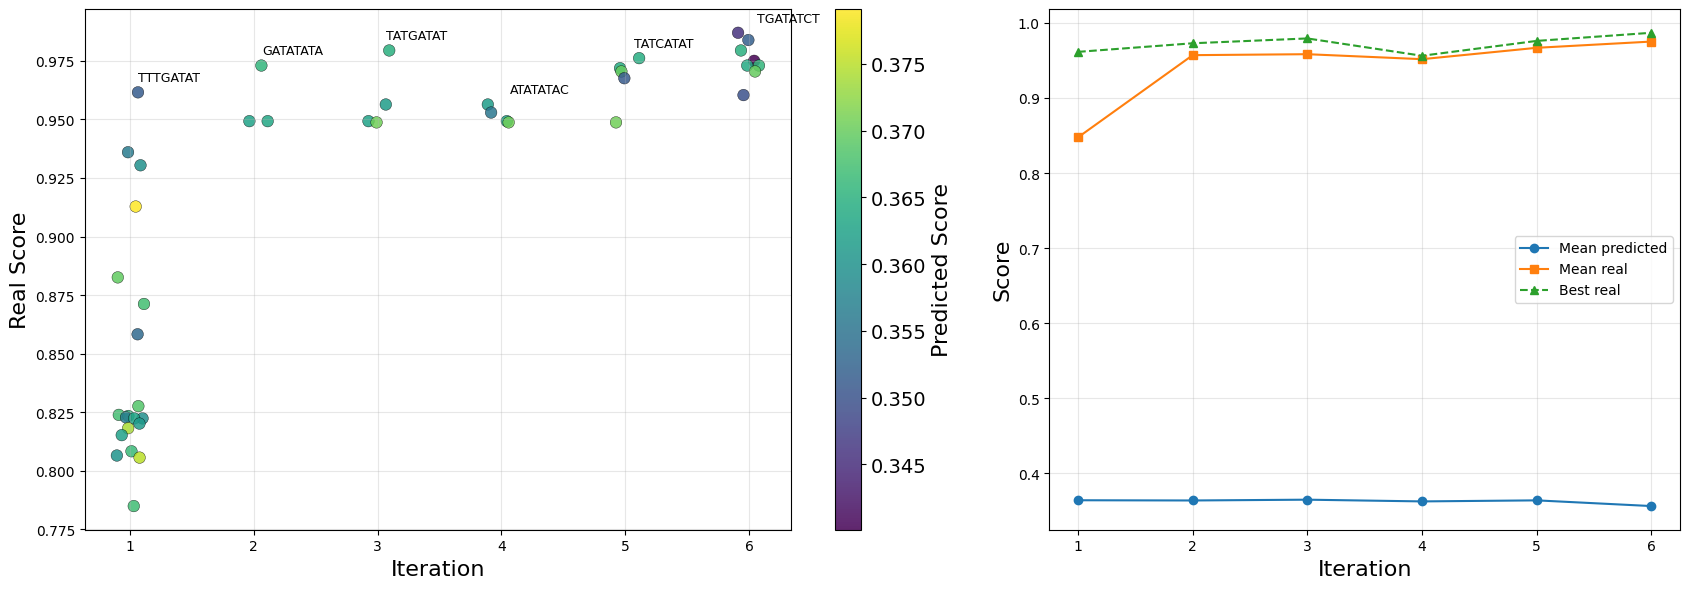

,iteration_plot,sequence,predicted_score,real_score
0,1,TTTGATAT,0.351247,0.961603
1,1,AGATATAC,0.356118,0.936029
2,1,ATACTATA,0.359677,0.930452
3,1,CATTGATA,0.379106,0.912836
4,1,TTTCGATA,0.369564,0.882582
5,1,ATTAGATA,0.367310,0.871222
6,1,ATTGTATC,0.353398,0.858286
7,1,TTTAAATA,0.368520,0.827588
8,1,AGTATAAT,0.367311,0.823857
9,1,ATAAAATA,0.365181,0.823393


,iteration_plot,n_sequences,mean_predicted,mean_real,best_predicted,best_real
0,1,20,0.364141,0.847713,0.379106,0.961603
1,2,3,0.363841,0.957211,0.365642,0.973045
2,3,4,0.364903,0.958490,0.370698,0.979487
3,4,4,0.362597,0.951859,0.370698,0.956407
4,5,5,0.363991,0.967004,0.370698,0.976199
5,6,8,0.356403,0.975317,0.369827,0.987033


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def mutation_to_sequence_label(seq, alphabet="ACGT"):
    arr = np.asarray(seq)

    if arr.ndim == 2:
        arr = arr.argmax(axis=-1)

    if arr.ndim == 1 and set(np.unique(arr)).issubset({0, 1}) and arr.size % len(alphabet) == 0:
        arr = arr.reshape(-1, len(alphabet)).argmax(axis=-1)

    if arr.ndim == 1 and np.issubdtype(arr.dtype, np.integer):
        arr = arr.astype(int)
        if arr.min() >= 0 and arr.max() < len(alphabet):
            return "".join(alphabet[index] for index in arr)

    return str(seq)


plot_df = values_df.copy()
plot_df["iteration_plot"] = plot_df["iteration"].astype(int)
if plot_df["iteration_plot"].min() == 0:
    plot_df["iteration_plot"] += 1

plot_df["sequence"] = plot_df["mutation"].apply(mutation_to_sequence_label)
plot_df = plot_df.sort_values(["iteration_plot", "real_score"], ascending=[True, False]).reset_index(drop=True)

summary_df = (
    plot_df
    .groupby("iteration_plot", as_index=False)
    .agg(
        n_sequences=("sequence", "nunique"),
        mean_predicted=("predicted_score", "mean"),
        mean_real=("real_score", "mean"),
        best_predicted=("predicted_score", "max"),
        best_real=("real_score", "max"),
    )
)

best_per_iteration = plot_df.loc[plot_df.groupby("iteration_plot")["real_score"].idxmax()].copy()

fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={"width_ratios": [1.4, 1]})

rng = np.random.default_rng(42)
plot_df["iteration_jitter"] = plot_df["iteration_plot"] + rng.uniform(-0.12, 0.12, len(plot_df))

scatter = axes[0].scatter(
    plot_df["iteration_jitter"],
    plot_df["real_score"],
    c=plot_df["predicted_score"],
    cmap="viridis",
    s=70,
    alpha=0.85,
    edgecolors="black",
    linewidths=0.3,
)

for _, row in best_per_iteration.iterrows():
    axes[0].annotate(
        row["sequence"],
        (row["iteration_plot"], row["real_score"]),
        xytext=(6, 8),
        textcoords="offset points",
        fontsize=9,
    )

#axes[0].set_title("Found Sequences by Iteration")
axes[0].set_xlabel("Iteration", fontsize=16)
axes[0].set_ylabel("Real Score", fontsize=16)
axes[0].set_xticks(sorted(plot_df["iteration_plot"].unique()))
axes[0].grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label("Predicted Score", fontsize=16)
cbar.ax.tick_params(labelsize=14)

axes[1].plot(summary_df["iteration_plot"], summary_df["mean_predicted"], marker="o", label="Mean predicted")
axes[1].plot(summary_df["iteration_plot"], summary_df["mean_real"], marker="s", label="Mean real")
axes[1].plot(summary_df["iteration_plot"], summary_df["best_real"], marker="^", linestyle="--", label="Best real")
#axes[1].set_title("Score Trend per Iteration", fontsize=16)
axes[1].set_xlabel("Iteration", fontsize=16)
axes[1].set_ylabel("Score", fontsize=16)
axes[1].set_xticks(summary_df["iteration_plot"])
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

display(plot_df[["iteration_plot", "sequence", "predicted_score", "real_score"]])
display(summary_df)


In [9]:
import numpy as np
import ast

def to_seq_tuple(x):
    # mutation/encoded value can be ndarray, list, tuple, or string
    if isinstance(x, np.ndarray):
        return tuple(x.astype(int).tolist())
    if isinstance(x, list):
        return tuple(int(v) for v in x)
    if isinstance(x, tuple):
        return tuple(int(v) for v in x)
    if isinstance(x, str):
        s = x.strip()
        # format like "[1, 2, 3, 0, ...]"
        if "," in s:
            return tuple(int(v) for v in ast.literal_eval(s))
        # format like "[1 2 3 0 ...]"
        s = s.strip("[]")
        return tuple(np.fromstring(s, sep=" ", dtype=int).tolist())
    raise TypeError(f"Unsupported type: {type(x)}")

values_df["mutation"] = values_df["mutation"].apply(to_seq_tuple)


### Results without duplicates

Spearman Correlation: -0.3468


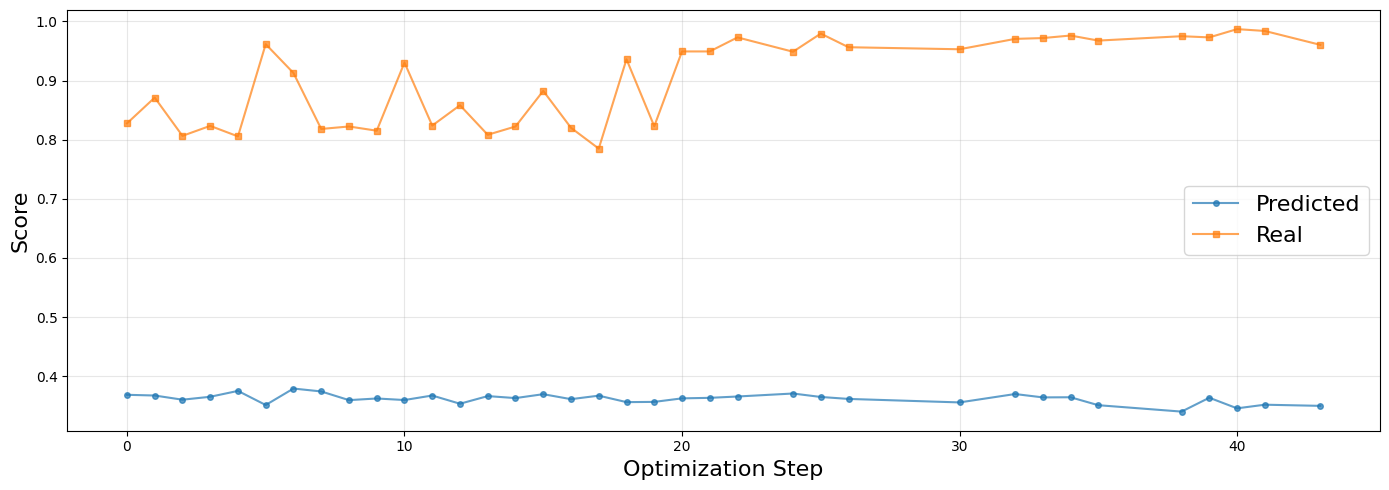

In [10]:
values_copy = values_df.copy()
values_copy['_seq_tuple'] = values_copy['mutation'].apply(lambda seq: tuple(seq))
values_copy.drop_duplicates(subset=['_seq_tuple'], inplace=True)

plot_results(values_copy)

### Results Normalized

Spearman Correlation: -0.3468


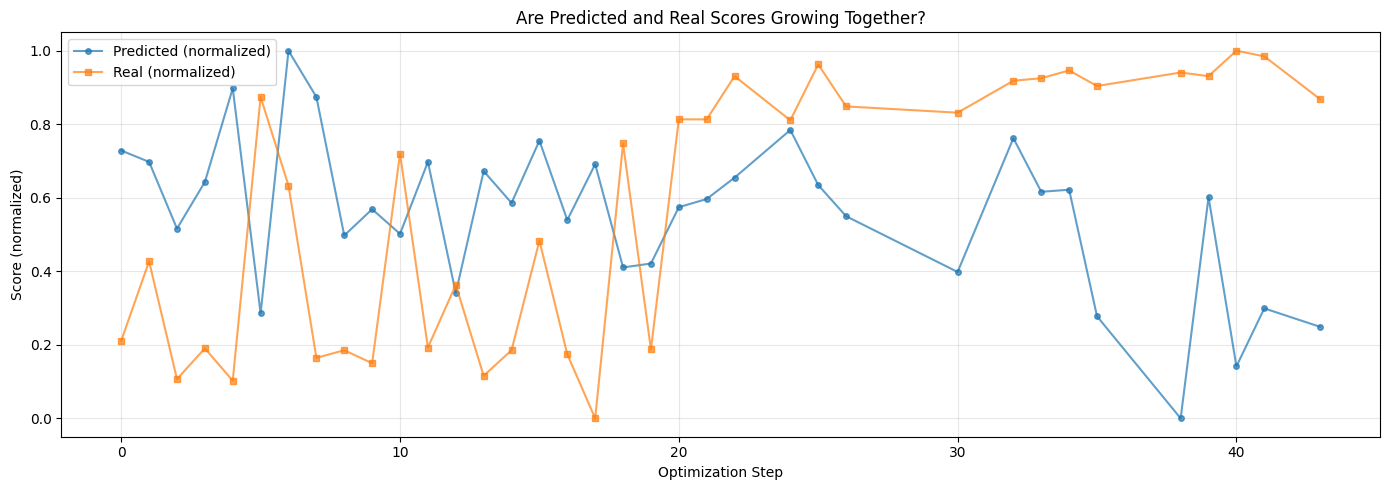

In [11]:
from main_scorer import plot_results_normalized
plot_results_normalized(values_copy)

## Results plotted per Testset
All sequences which are not in the regarding testset are dropped. The oracle-surrogate comparison and the trajectory is plotted for each Testset

In [12]:
from models.oracle import oracle_lookup

def lookup_oracle_testset(values, oracle):
    """ Look up real scores in generated sequences. If not found, drop the row. """
    drop_cont = 0
    scores = []
    for seq in values['mutation']:
        score = oracle_lookup(oracle, seq)
        if score is not None and score > 0.0:
            scores.append(score)
        else:
            scores.append(np.nan)
            drop_cont += 1
    print(f'Number of sequences not found in oracle: {drop_cont}')
    values['real_score'] = scores
    return values


### Test A:

Number of sequences not found in oracle: 34
Spearman Correlation: 0.1758


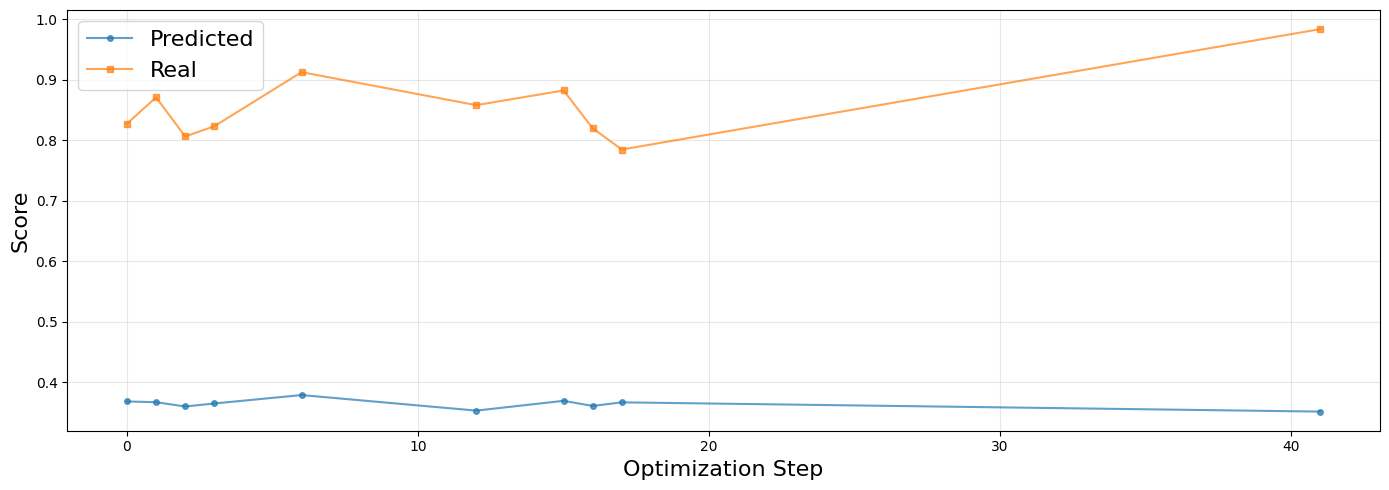

In [13]:
values_copy = values_df.copy()
values_copy.drop(columns=['real_score'], errors='ignore', inplace=True) # Drop real_score if it already exists to avoid confusion
test_a_oracle = build_oracle_df(df[df['split'] == 'test_a'])
test_a_df = lookup_oracle_testset(values_copy, test_a_oracle)
# drop rows with NaN real_score (sequences not found in oracle)
test_a_df = test_a_df.dropna(subset=['real_score'], inplace=False)
plot_results(test_a_df, "Predicted vs Real Scores (Test A)")


/var/folders/_2/6p52z75d21dc91tc6ss7n6w80000gn/T/ipykernel_2590/339187500.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_a_df['mutation'] = test_a_df['mutation'].apply(
/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


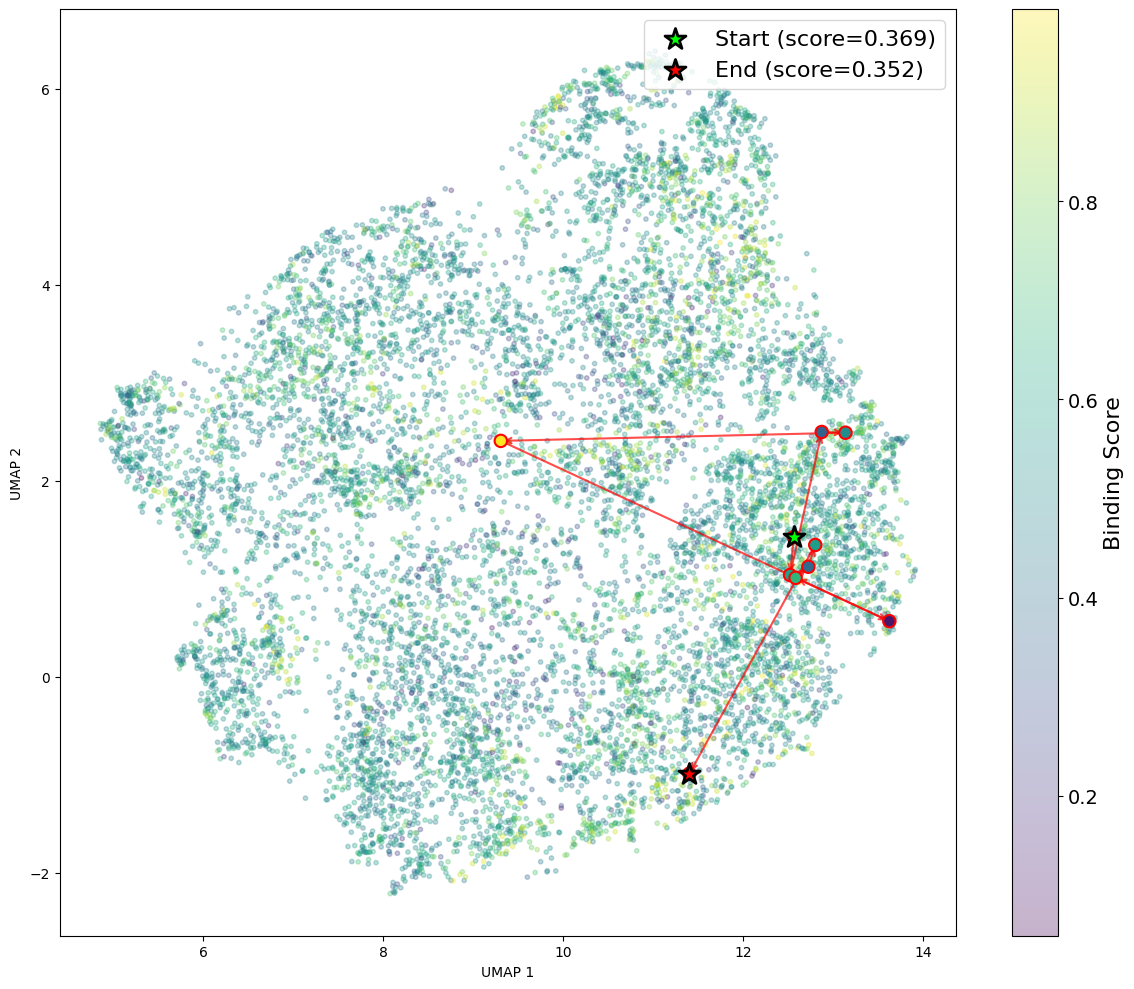

In [14]:
test_a_df['mutation'] = test_a_df['mutation'].apply(
    lambda seq: tf.one_hot(list(seq), depth=4).numpy().flatten()
)

plot_umap_embedding(df, 'test_a', test_a_df, vocab_size=4)

### Test B:

Number of sequences not found in oracle: 29
Spearman Correlation: -0.4446


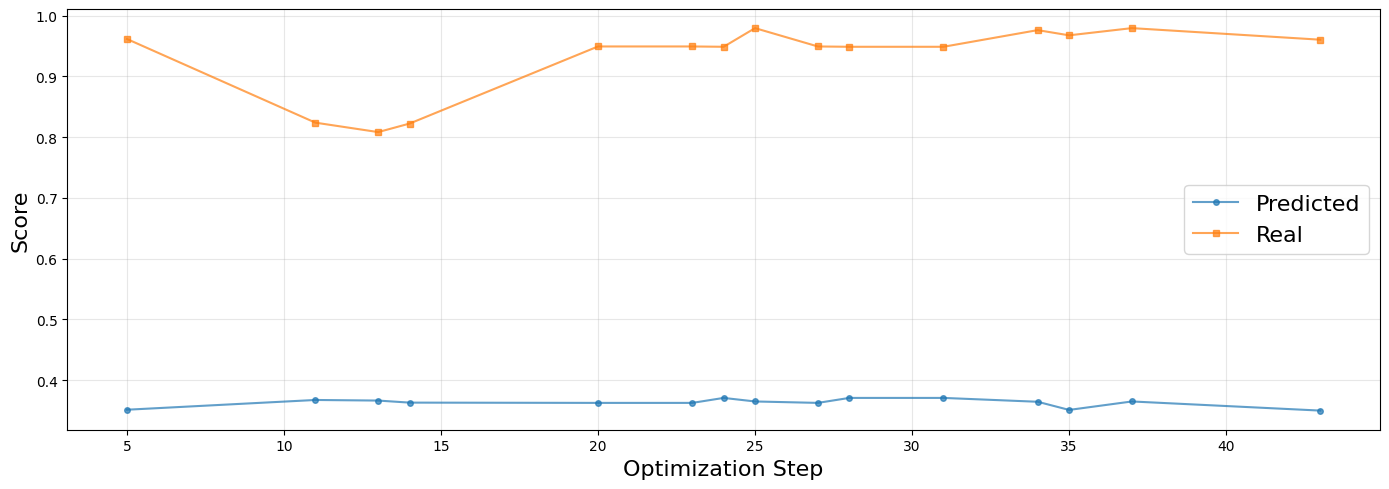

In [15]:
values_copy = values_df.copy()
values_copy.drop(columns=['real_score'], errors='ignore', inplace=True) # Drop real_score if it already exists to avoid confusion
test_b_oracle = build_oracle_df(df[df['split'] == 'test_b'])
test_b_df = lookup_oracle_testset(values_copy, test_b_oracle)
# drop rows with NaN real_score (sequences not found in oracle)
test_b_df = test_b_df.dropna(subset=['real_score'], inplace=False)
plot_results(test_b_df)

/var/folders/_2/6p52z75d21dc91tc6ss7n6w80000gn/T/ipykernel_2590/3644433719.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_b_df['mutation'] = test_b_df['mutation'].apply(
/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


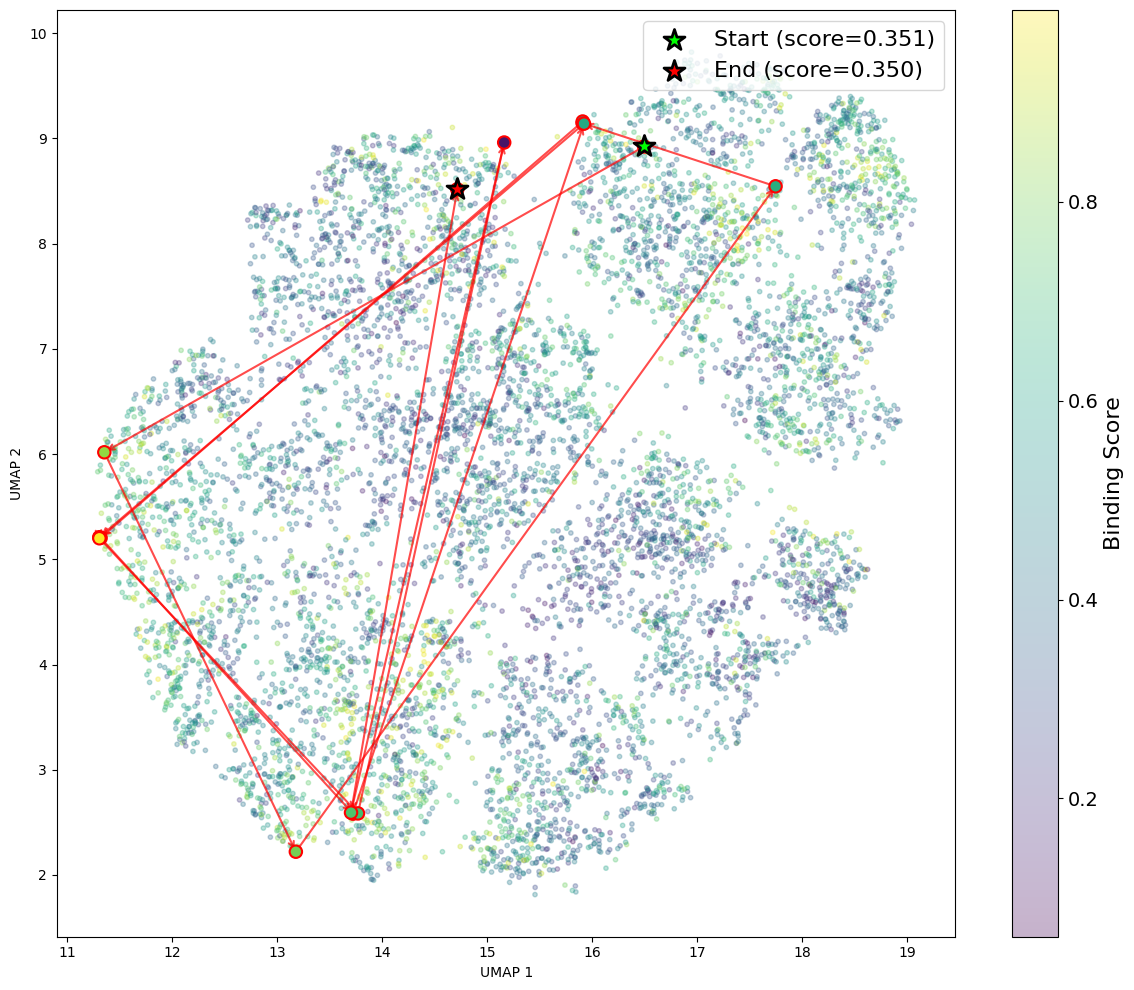

In [16]:
test_b_df['mutation'] = test_b_df['mutation'].apply(
    lambda seq: tf.one_hot(list(seq), depth=4).numpy().flatten()
)
plot_umap_embedding(df, 'test_b', test_b_df, vocab_size=4)

### Test C

Number of sequences not found in oracle: 25
Spearman Correlation: -0.1550


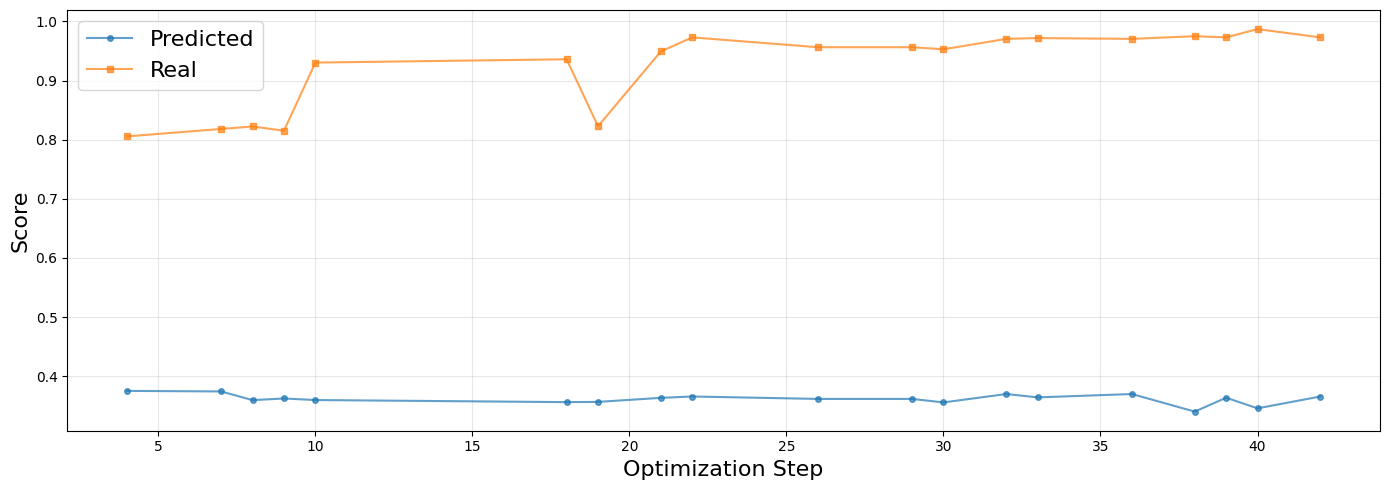

In [17]:
values_copy = values_df.copy()
values_copy.drop(columns=['real_score'], errors='ignore', inplace=True) # Drop real_score if it already exists to avoid confusion
test_c_oracle = build_oracle_df(df[df['split'] == 'test_c'])
test_c_df = lookup_oracle_testset(values_copy, test_c_oracle)
test_c_df = test_c_df.dropna(subset=['real_score'], inplace=False)
plot_results(test_c_df)

/var/folders/_2/6p52z75d21dc91tc6ss7n6w80000gn/T/ipykernel_2590/2665538143.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_c_df['mutation'] = test_c_df['mutation'].apply(
/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


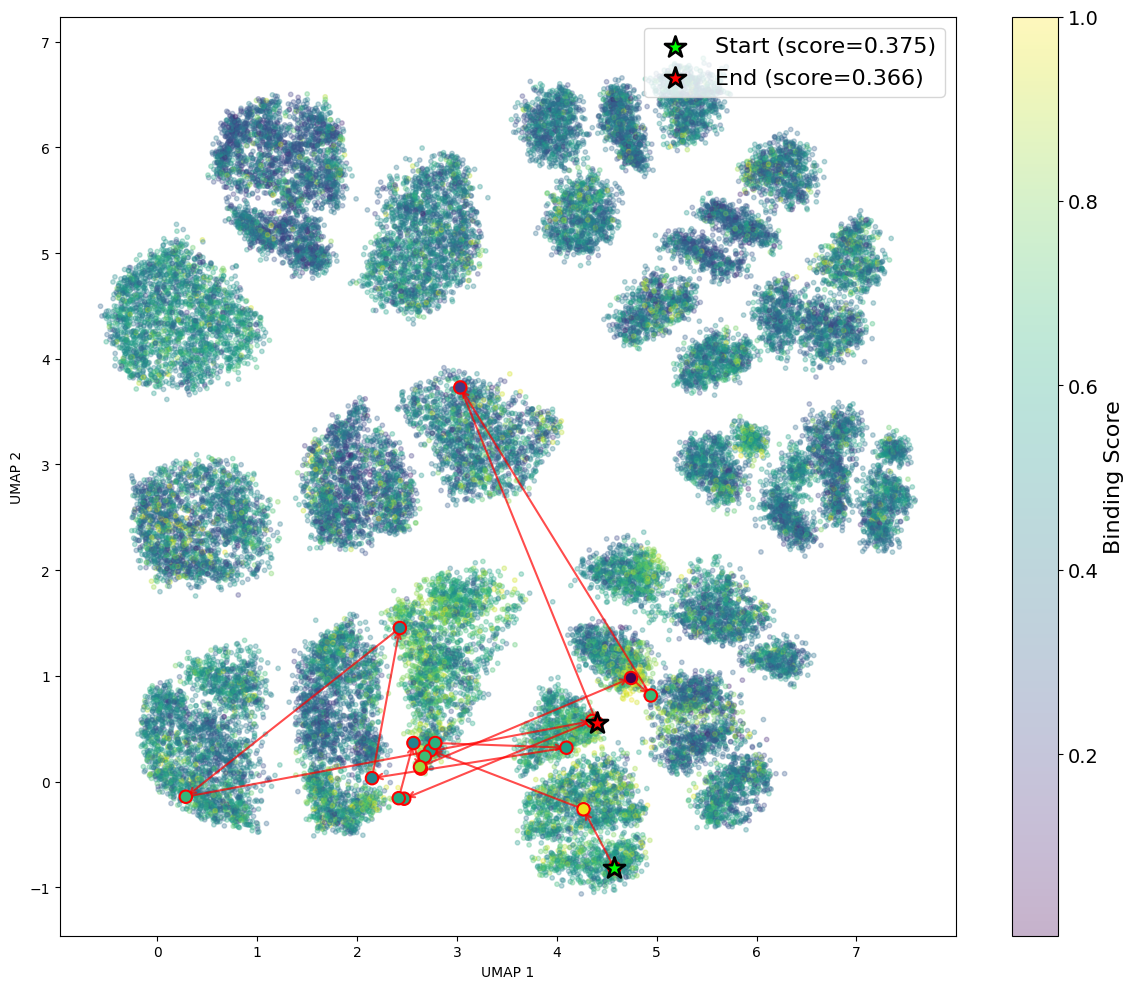

In [18]:
test_c_df['mutation'] = test_c_df['mutation'].apply(
    lambda seq: tf.one_hot(list(seq), depth=4).numpy().flatten()
)

plot_umap_embedding(df, 'test_c', test_c_df, vocab_size=4)